In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# Model persistence
import joblib

# Install UCI dataset access library
!pip install -q ucimlrepo

# Import
from ucimlrepo import fetch_ucirepo

import os

In [2]:
# Fetch Bank Marketing dataset
bank_marketing = fetch_ucirepo(id=222)

# Features and target
X = bank_marketing.data.features
y = bank_marketing.data.targets

print("Features:", X.shape)
print("Target:", y.shape)

display(X.head())
display(y.head())

Features: (45211, 16)
Target: (45211, 1)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


,y
0,no
1,no
2,no
3,no
4,no


In [3]:
X.info()
X.describe(include="all").T
y.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
dtypes: int64(7), object(9)
memory usage: 5.5+ MB


,count
y,
no,39922
yes,5289


In [4]:
# The target y dataframe needs to be converted to 1-D series and encoded
y = y.iloc[:, 0].map({'no': 0, 'yes': 1})

In [5]:
# stratified split on dataset into train and test as classes are not perfectly balanced
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(36168, 16)
(9043, 16)


In [6]:
test_data = X_test.copy()
test_data["y"] = y_test

test_data.to_csv("test_data.csv", index=False)

In [7]:
numeric_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X_train.select_dtypes(
    include=['object']
).columns

print("Numerical:", list(numeric_features))
print("Categorical:", list(categorical_features))

Numerical: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [10]:
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    print(f"{name} trained")

Logistic Regression trained
Decision Tree trained
KNN trained
Random Forest trained


In [11]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"{name}: {y_pred[:5]}")

Logistic Regression: [0 0 0 0 0]
Decision Tree: [0 0 0 0 0]
KNN: [0 0 0 0 0]
Random Forest: [0 0 0 0 0]


In [12]:
# For Naive Bayes preprocessor

nb_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features)
    ]
)

In [13]:
nb_pipeline = Pipeline([
    ('preprocessor', nb_preprocessor),
    ('model', GaussianNB())
])

nb_pipeline.fit(X_train, y_train)

trained_models["Naive Bayes"] = nb_pipeline

In [14]:
print(trained_models.keys())

dict_keys(['Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest', 'Naive Bayes'])


In [15]:
results = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.901250,0.905574,0.644483,0.347826,0.451811,0.426058
1,Decision Tree,0.874599,0.701457,0.464880,0.475425,0.470093,0.399021
2,KNN,0.896163,0.827721,0.599002,0.340265,0.433996,0.400128
3,Random Forest,0.904456,0.926286,0.650621,0.396030,0.492362,0.459724
4,Naive Bayes,0.854805,0.810095,0.405904,0.519849,0.455864,0.377358


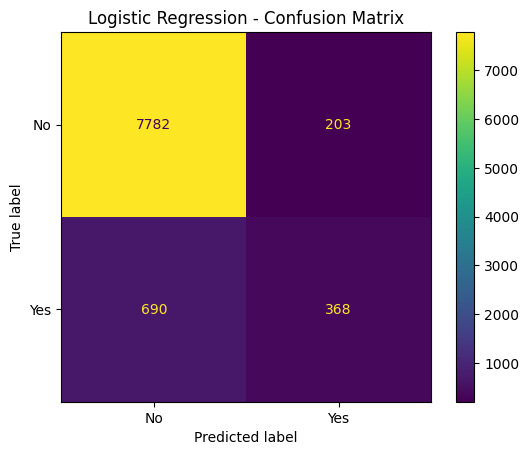

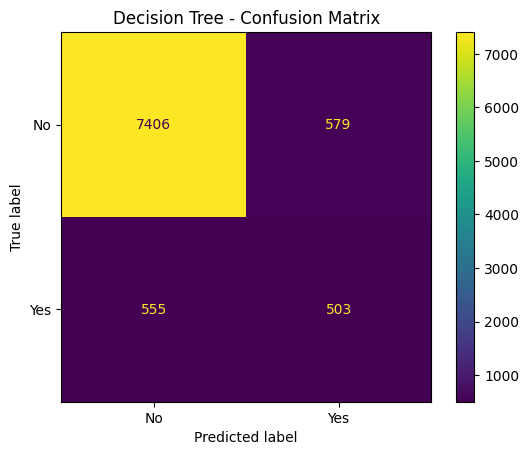

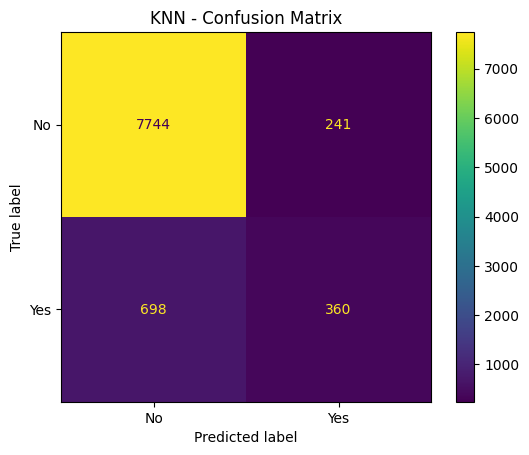

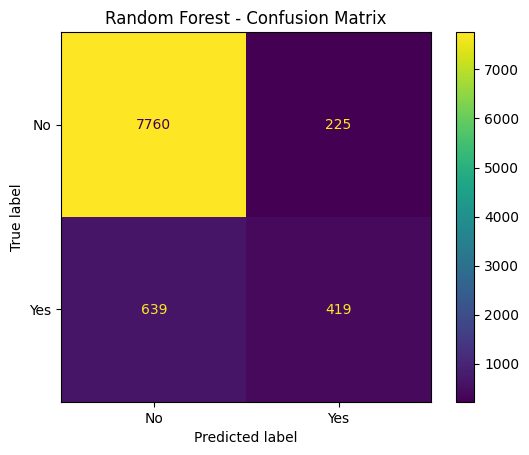

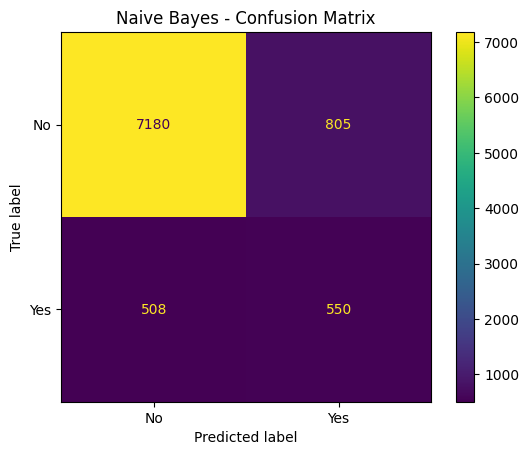

In [16]:
# confusion matrices for all models

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No", "Yes"]
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [17]:
os.makedirs("models", exist_ok=True)

In [18]:
for name, model in trained_models.items():
    filename = name.lower().replace(" ", "_") + ".joblib"
    joblib.dump(model, f"models/{filename}")

print("Models saved successfully.")

Models saved successfully.
